In [1]:
import gymnasium as gym
import math
import random
import matplotlib.pyplot as plt
from collections import namedtuple, deque
import warnings
import numpy as np
from tqdm import tqdm
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

Create environment with Gymnasium

In [2]:
env = gym.make("CartPole-v1")

In [3]:
state, info = env.reset()
state_dim = len(state)
action_dim = env.action_space.n

First create an object class to use to construct both action-value and target action-value functions

In [4]:
class NN(nn.Module):
    def __init__(self, state_dim, hidden_dim, layer_num, action_dim):
        super(NN, self).__init__()

        layers = []
        # input layer
        layers.append(nn.Linear(state_dim, hidden_dim))
        layers.append(nn.ReLU())

        # hidden layers
        if layer_num >= 2:
            for i in range(layer_num - 1):
                layers.append(nn.Linear(hidden_dim, hidden_dim))
                layers.append(nn.ReLU())
        
        # output layer
        layers.append(nn.Linear(hidden_dim, action_dim))

        self.model = nn.Sequential(*layers)
    
    def forward(self, X):
        return self.model(X)

In [5]:
hidden_dim = 128
layer_num = 1

In [6]:
# initiate action-value function and target function
act_val_func = NN(state_dim, hidden_dim, layer_num, action_dim)
target_func = NN(state_dim, hidden_dim, layer_num, action_dim)

# initially, the target function and action-value function are having identical weights identical
target_func.load_state_dict(act_val_func.state_dict())

<All keys matched successfully>

create an algorithm for action decision (epsilon-greedy)

In [7]:
eps_start_linear = 1
eps_end_linear = 0.1
eps_start_exponential = 0.9
eps_end_exponential = 0.01
eps_decay = 2500

def exponential_action_decision(t, state):
    """
    The vanilla DQN purely from its original psuedo-code have used epsilon-greedy method for action selection. 
    However, it is observed that the epsilon-greedy method produced instability that caused the training to fail and pull the agent toward poorer performance. 
    Hence, strong deminishing epsilon-greedy method is employed.
    """
    eps = eps_end_exponential + (eps_start_exponential - eps_end_exponential) * math.exp(-1. * t / eps_decay)
    prob = random.random()

    if prob >= eps:
        with torch.no_grad():
            action = act_val_func(state).max(0).indices
    else:
        action = env.action_space.sample()
    return torch.tensor([action])

def linear_action_decision(t, state):
    if t > eps_decay:
        eps = eps_end_linear
    else:
        eps = (eps_end_linear - eps_start_linear)*(t/eps_decay) + eps_start_linear
    prob = random.random()

    if prob >= eps:
        with torch.no_grad():
            action = act_val_func(state).max(0).indices
    else:
        action = env.action_space.sample()
    return torch.tensor([action])

create replay memory data storage and start the training loop

In [8]:
# training hyperparameters
tot_episodes = 600
minibatch_size = 128
max_step_per_episode = 500
gamma = 0.99
lr = 3e-4
C = 240
replay_capa = 10000
TAU=0.005

In [9]:
transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'terminal_flag'))

if max_step_per_episode > env.spec.max_episode_steps:
    warnings.warn(f"By default, max steps in Gymnasium {env.spec.id} is set as {env.spec.max_episode_steps}.\nYou selected max_step_per_episode bigger than default max step (max_step_per_episode={max_step_per_episode}) so each episode will terminate before your max iteration count.")

In [10]:
criterion_openai = nn.SmoothL1Loss()
criterion_vanilla = nn.MSELoss()

In [11]:
seeds = [9527, 2976, 4522, 139, 7397]

In [12]:
# this is a list that will store the return of each episode
returns_vanilla = np.zeros((len(seeds), tot_episodes))
returns_openai = np.zeros((len(seeds), tot_episodes))

In [ ]:
seed_count = 0
for seed in seeds:
    # fixing seed
    random.seed(seed)
    torch.manual_seed(seed)

    env.reset(seed=seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    # initiate action-value function and target function
    act_val_func = NN(state_dim, hidden_dim, layer_num, action_dim)
    target_func = NN(state_dim, hidden_dim, layer_num, action_dim)

    # initially, the target function and action-value function are having identical weights identical
    target_func.load_state_dict(act_val_func.state_dict())

    optimizer = optim.AdamW(act_val_func.parameters(), lr=lr, amsgrad=True)

    replay_memory = deque([], maxlen=replay_capa)
    
    c_count = 0
    global_step_count = 0

    for i in tqdm(range(tot_episodes)):
        state, info = env.reset()
        returns_ = 0

        for j in range(max_step_per_episode):
            state = torch.Tensor(state)
            step_count = i*max_step_per_episode + j
            action = linear_action_decision(global_step_count, state)
            next_state, reward, terminate, truncate, infro = env.step(action.item())
            done = terminate

            global_step_count += 1
            returns_ += reward

            reward = torch.Tensor(np.array(reward))
            if done:
                next_state = None
            else:
                next_state = torch.Tensor(next_state)

            replay = transition(state, action, reward, next_state, done)
            replay_memory.append(replay)

            if minibatch_size <= len(replay_memory):
                minibatch = random.sample(replay_memory, minibatch_size)
                minibatch = transition(*zip(*minibatch))

                state_batch = torch.stack(minibatch.state)
                action_batch = torch.tensor(minibatch.action).unsqueeze(1)
                reward_batch = torch.tensor(minibatch.reward)
                done_batch = torch.tensor(minibatch.terminal_flag, dtype=torch.bool)

                #need to check if thit was terminal step or not, before calculating target return
                non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, minibatch.next_state)), dtype=torch.bool)
                non_final_next_states = torch.stack([s for s in minibatch.next_state if s is not None])

                #calculate target return
                q = act_val_func(state_batch).gather(1, action_batch)
                next_state_values = torch.zeros(minibatch_size)
                with torch.no_grad():
                    next_state_values[non_final_mask] = target_func(non_final_next_states).max(1)[0]
                y = reward_batch + (gamma * next_state_values)
                
                # perform gradient descent step to update action-value function parameters
                loss = criterion_vanilla(q.squeeze(), y)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                #update the target function to current function for every C step
                if c_count >= C:
                    target_func.load_state_dict(act_val_func.state_dict())
                    c_count = 0
                c_count += 1
                
            if done:
                break
            else:
                state = next_state

        returns_vanilla[seed_count, i] = returns_
    seed_count += 1

100%|██████████| 600/600 [04:57<00:00,  2.02it/s]


This is the version that mimicked the CartPole example from OpenAIGymnasium

In [14]:
seed_count = 0
for seed in seeds:
    # fixing seed
    random.seed(seed)
    torch.manual_seed(seed)

    env.reset(seed=seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    # initiate action-value function and target function
    act_val_func = NN(state_dim, hidden_dim, layer_num, action_dim)
    target_func = NN(state_dim, hidden_dim, layer_num, action_dim)

    # initially, the target function and action-value function are having identical weights identical
    target_func.load_state_dict(act_val_func.state_dict())

    optimizer = optim.AdamW(act_val_func.parameters(), lr=lr, amsgrad=True)

    replay_memory = deque([], maxlen=replay_capa)

    global_step_count = 0

    for i in tqdm(range(tot_episodes)):
        state, info = env.reset()
        returns_ = 0

        for j in range(max_step_per_episode):
            state = torch.Tensor(state)
            step_count = i*max_step_per_episode + j
            action = exponential_action_decision(global_step_count, state)
            global_step_count += 1
            next_state, reward, terminate, truncate, info = env.step(action.item())
            done = terminate

            returns_ += reward

            reward = torch.Tensor(np.array(reward))
            if done:
                next_state = None
            else:
                next_state = torch.Tensor(next_state)

            replay = transition(state, action, reward, next_state, done)
            replay_memory.append(replay)
            
            if minibatch_size <= len(replay_memory):
                minibatch = random.sample(replay_memory, minibatch_size)
                minibatch = transition(*zip(*minibatch))

                state_batch = torch.stack(minibatch.state)
                action_batch = torch.tensor(minibatch.action).unsqueeze(1)
                reward_batch = torch.tensor(minibatch.reward)
                done_batch = torch.tensor(minibatch.terminal_flag, dtype=torch.bool)

                #need to check if thit was terminal step or not, before calculating target return
                non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, minibatch.next_state)), dtype=torch.bool)
                non_final_next_states = torch.stack([s for s in minibatch.next_state if s is not None])

                #calculate target return
                q = act_val_func(state_batch).gather(1, action_batch)
                next_state_values = torch.zeros(minibatch_size)
                with torch.no_grad():
                    next_state_values[non_final_mask] = target_func(non_final_next_states).max(1)[0]
                y = reward_batch + (gamma * next_state_values)
                
                # perform gradient descent step to update action-value function parameters
                loss = criterion_openai(q.squeeze(), y)
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_value_(act_val_func.parameters(), 100)
                optimizer.step()

                #update the target function to current function for every C step
                target_net_state_dict = target_func.state_dict()
                policy_net_state_dict = act_val_func.state_dict()
                for key in policy_net_state_dict:
                    target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
                target_func.load_state_dict(target_net_state_dict)

            if done:
                break
            else:
                state = next_state

        returns_openai[seed_count, i] = returns_
    seed_count += 1

100%|██████████| 600/600 [02:57<00:00,  3.38it/s]


result

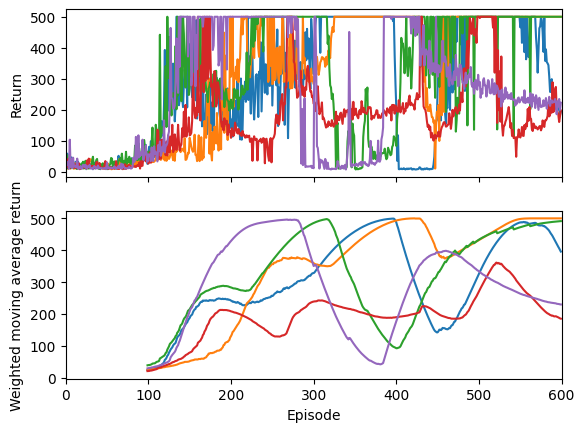

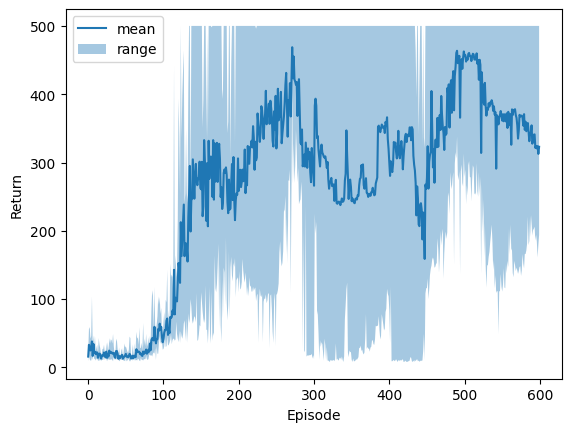

In [15]:
fig,(ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True)

window_size = 100
weights = np.arange(1, window_size + 1)

for i in range(returns_vanilla.shape[0]):
    data = pd.DataFrame(returns_vanilla[i,:])
    wma = data.rolling(window=window_size).apply(
        lambda x: np.dot(x, weights) / weights.sum(), 
        raw=True
    )
    ax1.plot(data)
    ax2.plot(wma)
ax1.set_ylabel("Return")
ax2.set_ylabel("Weighted moving average return")
ax2.set_xbound((0, tot_episodes))
ax2.set_xlabel("Episode")
plt.show()

# -------------------------------------------------------------------------------

min_, max_ = np.min(returns_vanilla, axis=0), np.max(returns_vanilla, axis=0)
mean = np.mean(returns_vanilla, axis=0)

plt.plot(mean, label="mean")
plt.fill_between(range(min_.shape[0]), min_, max_, alpha=0.4, label="range")
plt.legend()
plt.xlabel("Episode")
plt.ylabel("Return")
plt.show()

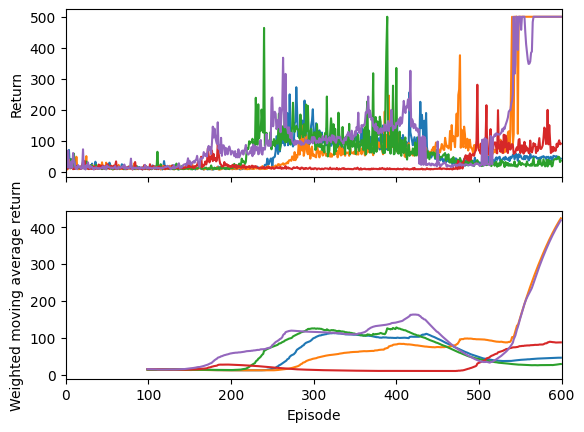

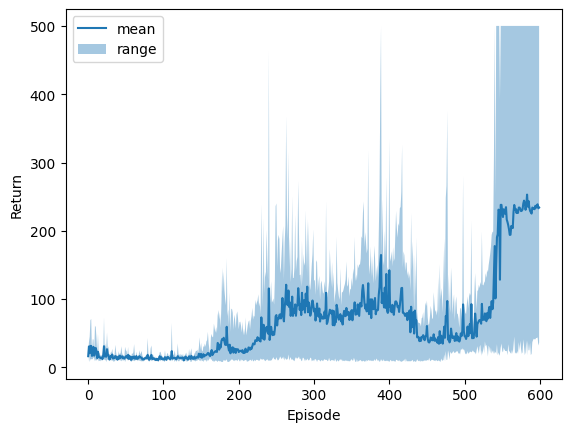

In [16]:
fig,(ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True)

window_size = 100
weights = np.arange(1, window_size + 1)

for i in range(returns_openai.shape[0]):
    data = pd.DataFrame(returns_openai[i,:])
    wma = data.rolling(window=window_size).apply(
        lambda x: np.dot(x, weights) / weights.sum(), 
        raw=True
    )
    ax1.plot(data)
    ax2.plot(wma)
ax1.set_ylabel("Return")
ax2.set_ylabel("Weighted moving average return")
ax2.set_xbound((0, tot_episodes))
ax2.set_xlabel("Episode")
plt.show()

# -------------------------------------------------------------------------------

min_, max_ = np.min(returns_openai, axis=0), np.max(returns_openai, axis=0)
mean = np.mean(returns_openai, axis=0)

plt.plot(mean, label="mean")
plt.fill_between(range(min_.shape[0]), min_, max_, alpha=0.4, label="range")
plt.legend()
plt.xlabel("Episode")
plt.ylabel("Return")
plt.show()